**Aleksander Hański 160315 and Michał Żurawski ??????**

In [42]:
import kagglehub
import shutil
import os

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from itertools import combinations
import pulp
from pulp import (
    LpProblem, LpMinimize, LpVariable, LpStatus,
    lpSum, value, GLPK_CMD
)
import sys

# Loading dataset:

In [43]:
# Download to kaggle cache first
cache_path = kagglehub.dataset_download("abdulmalik1518/cars-datasets-2025")

# Copy to your desired local folder
destination = "./dataset"  # ← change this to your preferred path
os.makedirs(destination, exist_ok=True)
shutil.copytree(cache_path, destination, dirs_exist_ok=True)

print("Files saved to:", destination)
for f in os.listdir(destination):
    print(" -", f)

Files saved to: ./dataset
 - Cars Datasets 2025.csv


In [44]:
df = pd.read_csv("./dataset/Cars Datasets 2025.csv", encoding="cp1252")

df.head

<bound method NDFrame.head of      Company Names         Cars Names                             Engines  \
0          FERRARI      SF90 STRADALE                                  V8   
1      ROLLS ROYCE            PHANTOM                                 V12   
2             Ford                KA+                         1.2L Petrol   
3         MERCEDES            GT 63 S                                  V8   
4             AUDI         AUDI R8 Gt                                 V10   
...            ...                ...                                 ...   
1213        Toyota       Crown Signia                      2.5L Hybrid I4   
1214        Toyota  4Runner (6th Gen)  2.4L Turbo I4 (i-FORCE MAX Hybrid)   
1215        Toyota      Corolla Cross              2.0L Gas / 2.0L Hybrid   
1216        Toyota             C-HR+                   1.8L / 2.0L Hybrid   
1217        Toyota     RAV4 (6th Gen)        2.5L Hybrid / Plug-in Hybrid   

        CC/Battery Capacity    HorsePower Tot

# Dataset preprocessing:

In [45]:
print(df.isnull().sum())

Company Names                0
Cars Names                   0
Engines                      0
CC/Battery Capacity          3
HorsePower                   0
Total Speed                  0
Performance(0 - 100 )KM/H    6
Cars Prices                  0
Fuel Types                   0
Seats                        0
Torque                       1
dtype: int64


In [46]:
df = df.dropna()

In [47]:
for col in df.columns:
    print(f"\n{col} ({df[col].nunique()} unique values) | type: {df[col].dtype}")
    if df[col].nunique() < 20: 
        print(df[col].unique())


Company Names (37 unique values) | type: object

Cars Names (1193 unique values) | type: object

Engines (350 unique values) | type: object

CC/Battery Capacity (309 unique values) | type: object

HorsePower (453 unique values) | type: object

Total Speed (113 unique values) | type: object

Performance(0 - 100 )KM/H (180 unique values) | type: object

Cars Prices (533 unique values) | type: object

Fuel Types (21 unique values) | type: object

Seats (17 unique values) | type: object
['2' '5' '4' '2+2' '7' '8' '12' '3' '9' '6' '1' '2–15' '2–7' '2–6' '7–8'
 '2–9' '2–12']

Torque (262 unique values) | type: object


## Seats:

In [48]:
print(df[df["Seats"].isin(["2+2", "2-6", "2-7","2-9", "2-12", "2-15", "7-8"])])

   Company Names   Cars Names  Engines CC/Battery Capacity HorsePower  \
11       FERRARI    PORTOFINO       V8            3,900 cc     592 hp   
12       FERRARI         ROMA       V8            3,900 cc     612 hp   
15       FERRARI  PORTOFINO M       V8            3,900 cc     612 hp   
16       FERRARI  ROMA SPIDER       V8            3,900 cc     612 hp   
18        TOYOTA    TOYOTA 86  BOXER-4            1,998 cc     205 hp   

   Total Speed Performance(0 - 100 )KM/H Cars Prices Fuel Types Seats  Torque  
11    320 km/h                   3.2 sec   $210,000      Petrol   2+2  760 Nm  
12    320 km/h                   3.4 sec   $230,000      Petrol   2+2  760 Nm  
15    320 km/h                   3.2 sec   $220,000      Petrol   2+2  760 Nm  
16    320 km/h                   3.4 sec   $240,000      Petrol   2+2  760 Nm  
18    226 km/h                   6.4 sec    $27,000      Petrol   2+2  205 Nm  


There are only alternatives with "2+2" seats.

In [49]:
df = df[df["Seats"].isin(['8','9','12'])]

print(len(df))

31


In [50]:
CRITERIA = {"Seats": ['8','9','12']}

## Total speed:

In [51]:
print(df["Total Speed"])

197     209 km/h
286     160 km/h
327     180 km/h
387     210 km/h
414     210 km/h
451     155 km/h
677     190 km/h
678     190 km/h
712     190 km/h
741     200 km/h
751     180 km/h
753     180 km/h
754     180 km/h
759     180 km/h
763     180 km/h
764     200 km/h
771     200 km/h
780     200 km/h
783     210 km/h
784     210 km/h
798     210 km/h
801     210 km/h
808     210 km/h
814     210 km/h
818     210 km/h
834     220 km/h
847     220 km/h
856     220 km/h
867     220 km/h
875     220 km/h
1023    180 km/h
Name: Total Speed, dtype: object


In [52]:
df["Total Speed"] = df["Total Speed"].str.replace(" km/h", "").astype(int)
print(df["Total Speed"])

197     209
286     160
327     180
387     210
414     210
451     155
677     190
678     190
712     190
741     200
751     180
753     180
754     180
759     180
763     180
764     200
771     200
780     200
783     210
784     210
798     210
801     210
808     210
814     210
818     210
834     220
847     220
856     220
867     220
875     220
1023    180
Name: Total Speed, dtype: int64


155
220


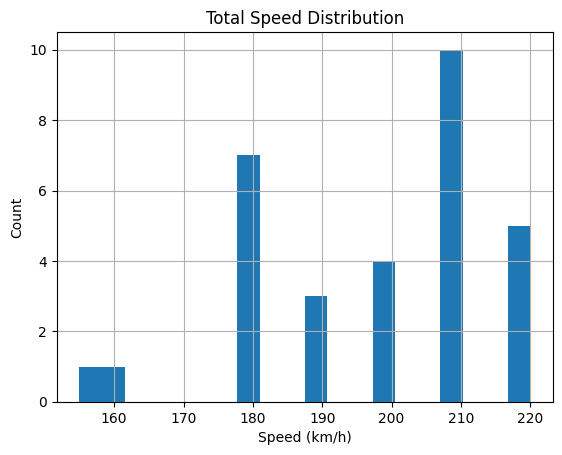

In [53]:
print(df["Total Speed"].min())
print(df["Total Speed"].max())

df["Total Speed"].hist(bins=20)
plt.title("Total Speed Distribution")
plt.xlabel("Speed (km/h)")
plt.ylabel("Count")
plt.show()

In [54]:
levels = np.linspace(df["Total Speed"].min(), df["Total Speed"].max(), 6)
levels

array([155., 168., 181., 194., 207., 220.])

In [55]:
CRITERIA["Total Speed"] = [f"≥{lvl}" for lvl in levels[:-1]]
print(CRITERIA)

{'Seats': ['8', '9', '12'], 'Total Speed': ['≥155.0', '≥168.0', '≥181.0', '≥194.0', '≥207.0']}


In [56]:
def snap_to_bin_label(value, levels):
    extended = np.append(levels, np.inf)
    idx = np.digitize(value, extended) - 1
    idx = np.clip(idx, 0, len(levels) - 1)
    # use levels[idx] but cap at second-to-last level
    label_idx = min(idx, len(levels) - 2)
    return f"≥{levels[label_idx]}"

df["Total Speed"] = df["Total Speed"].apply(lambda x: snap_to_bin_label(x, levels))
print(df["Total Speed"].unique())

['≥207.0' '≥155.0' '≥168.0' '≥181.0' '≥194.0']


## HorsePower:

In [57]:
print(df["HorsePower"])

197           285 hp
286           261 hp
327     102 - 204 hp
387           400 HP
414           400 HP
451           129 HP
677           392 hp
678           471 hp
712           355 hp
741           420 hp
751           355 hp
753           355 hp
754           355 hp
759           355 hp
763           355 hp
764           420 hp
771           420 hp
780           420 hp
783           355 hp
784           355 hp
798           420 hp
801           355 hp
808           355 hp
814           420 hp
818           355 hp
834           290 hp
847           290 hp
856           290 hp
867           290 hp
875           290 hp
1023    375 - 400 hp
Name: HorsePower, dtype: object


In [58]:
df["HorsePower"] = (df["HorsePower"]
    .str.replace(" hp", "", case=False)
    .str.replace(",", "")
    .str.strip()
    .str.split(" - ")
    .apply(lambda x: (int(x[0]) + int(x[1])) / 2 if len(x) == 2 else int(x[0]))
)
print(df["HorsePower"])

197     285.0
286     261.0
327     153.0
387     400.0
414     400.0
451     129.0
677     392.0
678     471.0
712     355.0
741     420.0
751     355.0
753     355.0
754     355.0
759     355.0
763     355.0
764     420.0
771     420.0
780     420.0
783     355.0
784     355.0
798     420.0
801     355.0
808     355.0
814     420.0
818     355.0
834     290.0
847     290.0
856     290.0
867     290.0
875     290.0
1023    387.5
Name: HorsePower, dtype: float64


129.0
471.0


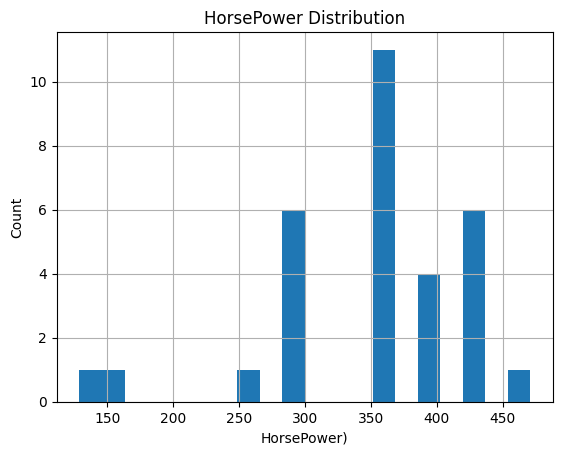

In [59]:
print(df["HorsePower"].min())
print(df["HorsePower"].max())

df["HorsePower"].hist(bins=20)
plt.title("HorsePower Distribution")
plt.xlabel("HorsePower)")
plt.ylabel("Count")
plt.show()

In [60]:
levels = np.linspace(df["HorsePower"].min(), df["HorsePower"].max(), 6)
levels

CRITERIA["HorsePower"] = [f"≥{lvl}" for lvl in levels[:-1]]
print(CRITERIA)

df["HorsePower"] = df["HorsePower"].apply(lambda x: snap_to_bin_label(x, levels))
print(df["HorsePower"].unique())

{'Seats': ['8', '9', '12'], 'Total Speed': ['≥155.0', '≥168.0', '≥181.0', '≥194.0', '≥207.0'], 'HorsePower': ['≥129.0', '≥197.4', '≥265.8', '≥334.20000000000005', '≥402.6']}
['≥265.8' '≥197.4' '≥129.0' '≥334.20000000000005' '≥402.6']


need to change it so that we have more bins within guys not being outliers

## Price:

In [61]:
print(df["Cars Prices"])

197              $40,000 
286              $33,000 
327              $35,000 
387              $51,000 
414              $65,300 
451              $28,000 
677              $63,595 
678              $91,495 
712              $59,900 
741              $82,400 
751              $64,400 
753              $56,995 
754              $62,495 
759              $65,500 
763              $57,400 
764              $61,100 
771              $72,800 
780              $93,800 
783              $71,505 
784              $73,305 
798              $76,805 
801              $65,000 
808              $75,000 
814              $90,000 
818              $78,000 
834              $42,500 
847              $39,500 
856              $47,000 
867              $43,500 
875              $45,500 
1023    $50,000 - $75,000
Name: Cars Prices, dtype: object


In [62]:
df["Cars Prices"] = (df["Cars Prices"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "")
    .str.strip()
    .str.split(" - ")
    .apply(lambda x: (int(x[0]) + int(x[1])) / 2 if len(x) == 2 else int(x[0]))
)
print(df["Cars Prices"])

197     40000.0
286     33000.0
327     35000.0
387     51000.0
414     65300.0
451     28000.0
677     63595.0
678     91495.0
712     59900.0
741     82400.0
751     64400.0
753     56995.0
754     62495.0
759     65500.0
763     57400.0
764     61100.0
771     72800.0
780     93800.0
783     71505.0
784     73305.0
798     76805.0
801     65000.0
808     75000.0
814     90000.0
818     78000.0
834     42500.0
847     39500.0
856     47000.0
867     43500.0
875     45500.0
1023    62500.0
Name: Cars Prices, dtype: float64


28000.0
93800.0


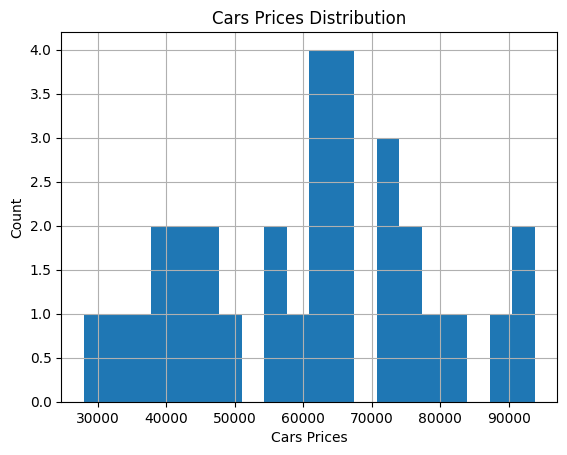

In [63]:
print(df["Cars Prices"].min())
print(df["Cars Prices"].max())

df["Cars Prices"].hist(bins=20)
plt.title("Cars Prices Distribution")
plt.xlabel("Cars Prices")
plt.ylabel("Count")
plt.show()

In [64]:
levels = np.linspace(df["Cars Prices"].max(), df["Cars Prices"].min(), 6)

levels_sorted = np.sort(levels)  # ascending for digitize
levels_desc = levels             # descending for labels (best → worst)

CRITERIA["Cars Prices"] = [f"≤{lvl}" for lvl in levels_desc[:-1]]

def snap_to_bin_label_cost(value, levels_asc, levels_desc):
    extended = np.append(levels_asc, np.inf)
    idx = np.digitize(value, extended) - 1
    idx = np.clip(idx, 0, len(levels_asc) - 2)
    # invert index so cheap = high bin
    inv_idx = len(levels_desc) - 2 - idx
    return f"≤{levels_desc[inv_idx]}"

df["Cars Prices"] = df["Cars Prices"].apply(
    lambda x: snap_to_bin_label_cost(x, levels_sorted, levels_desc)
)
print(df["Cars Prices"].unique())

['≤41160.0' '≤54320.0' '≤67480.0' '≤93800.0' '≤80640.0']


## Preferences:

In [65]:
print(df["Company Names"].unique())

['HONDA' 'Nissan' 'Volkswagen' 'Jeep' 'Chevrolet' 'GMC' 'Kia' 'Ford']


In [67]:
honda_cars = df[df["Company Names"] == "HONDA"]["Cars Names"].tolist()
nissan_cars = df[df["Company Names"] == "Nissan"]["Cars Names"].tolist()
kia_cars = df[df["Company Names"] == "Kia"]["Cars Names"].tolist()

PREFERENCES = []

PREFERENCES.append((honda_cars[0], nissan_cars[0]))

PREFERENCES.append((nissan_cars[0], kia_cars[0]))

PREFERENCES.append((kia_cars[0], honda_cars[0]))

# cycle

# UTA:

In [68]:
MIN_WEIGHT = 0.1 # floor per criterion
MAX_WEIGHT = 0.5 # ceiling per criterion
N_CRITERIA = len(CRITERIA)

print(CRITERIA)

{'Seats': ['8', '9', '12'], 'Total Speed': ['≥155.0', '≥168.0', '≥181.0', '≥194.0', '≥207.0'], 'HorsePower': ['≥129.0', '≥197.4', '≥265.8', '≥334.20000000000005', '≥402.6'], 'Cars Prices': ['≤93800.0', '≤80640.0', '≤67480.0', '≤54320.0', '≤41160.0']}


In [69]:
EPSILON = 0.01 

print(PREFERENCES)

[('PILOT', 'NV1500'), ('NV1500', 'Carnival EX'), ('Carnival EX', 'PILOT')]


In [70]:
selected_criteria = list(CRITERIA.keys())

ALTERNATIVES = {
    row["Cars Names"]: {col: row[col] for col in selected_criteria}
    for _, row in df.iterrows()
}

print(ALTERNATIVES)

{'PILOT': {'Seats': '8', 'Total Speed': '≥207.0', 'HorsePower': '≥265.8', 'Cars Prices': '≤41160.0'}, 'NV1500': {'Seats': '12', 'Total Speed': '≥155.0', 'HorsePower': '≥197.4', 'Cars Prices': '≤41160.0'}, 'Transporter': {'Seats': '9', 'Total Speed': '≥168.0', 'HorsePower': '≥129.0', 'Cars Prices': '≤41160.0'}, 'Armada': {'Seats': '8', 'Total Speed': '≥207.0', 'HorsePower': '≥334.20000000000005', 'Cars Prices': '≤54320.0'}, 'Armada Platinum': {'Seats': '8', 'Total Speed': '≥207.0', 'HorsePower': '≥334.20000000000005', 'Cars Prices': '≤67480.0'}, 'NV350 Caravan': {'Seats': '8', 'Total Speed': '≥155.0', 'HorsePower': '≥129.0', 'Cars Prices': '≤41160.0'}, 'Wagoneer': {'Seats': '8', 'Total Speed': '≥181.0', 'HorsePower': '≥334.20000000000005', 'Cars Prices': '≤67480.0'}, 'Grand Wagoneer': {'Seats': '8', 'Total Speed': '≥181.0', 'HorsePower': '≥402.6', 'Cars Prices': '≤93800.0'}, 'Suburban': {'Seats': '8', 'Total Speed': '≥181.0', 'HorsePower': '≥334.20000000000005', 'Cars Prices': '≤67480.0

In [ ]:
def build_and_solve(active_pref_indices, verbose=False):
    # only preferences with active_pref_indices are active

    prob = LpProblem("UTA_Inconsistency", LpMinimize)
 
    # Marginal value variables  u_c(x)
    # u[crit][level_index]
    u = {}
    for crit, levels in CRITERIA.items():
        u[crit] = {
            lvl: LpVariable(f"u_{crit}_{i}", lowBound=0, upBound=1)
            for i, lvl in enumerate(levels)
        }
 
    # monotonicity
    for crit, levels in CRITERIA.items():
        for i in range(len(levels) - 1):
            prob += (u[crit][levels[i]] <= u[crit][levels[i+1]],
                     f"Mono_{crit}_{i}")
 
    # Normalization: lowest level = 0 for each criterion
    for crit, levels in CRITERIA.items():
        prob += (u[crit][levels[0]] == 0, f"Norm_low_{crit}")
 
    # Normalization: sum of tops = 1
    prob += (
        lpSum(u[crit][levels[-1]] for crit, levels in CRITERIA.items()) == 1,
        "Norm_total"
    )
 
    # Weight bounds  (top level value = weight of criterion)
    for crit, levels in CRITERIA.items():
        w = u[crit][levels[-1]]
        prob += (w <= MAX_WEIGHT, f"MaxW_{crit}")
        prob += (w >= MIN_WEIGHT, f"MinW_{crit}")
 
    # Non-flatness constraints:
    # Ensure each criterion has at least two "steps" of ≥ 0.05
    # i.e. the spread from level[0] to level[-1] ≥ 0.15
    # AND at least one internal "jump" ≥ 0.04
    for crit, levels in CRITERIA.items():
        top = u[crit][levels[-1]]
        prob += (top >= 0.15, f"NonFlat_spread_{crit}")
        # At least one consecutive pair must differ by ≥ 0.04
        # Encoded via auxiliary binary + big-M – simpler: require
        # that the midpoint level is NOT equal to both ends,
        # i.e. u[mid] ≥ u[low] + 0.04  OR  u[high] ≥ u[mid] + 0.04
        # We enforce BOTH internal gaps together ≥ 0.04 (relaxed form)
        if len(levels) >= 3:
            mid = levels[len(levels) // 2]
            prob += (u[crit][mid] - u[crit][levels[0]] >= 0.04, f"NonFlat_lo_{crit}")
            prob += (u[crit][levels[-1]] - u[crit][mid] >= 0.04, f"NonFlat_hi_{crit}")
 
    # Utility of each alternative
    U = {}
    for alt, evals in ALTERNATIVES.items():
        U[alt] = lpSum(u[crit][evals[crit]] for crit in CRITERIA)
 
    # Preference constraints (only active ones)
    for idx in active_pref_indices:
        a, b = PREFERENCES[idx]
        prob += (U[a] >= U[b] + EPSILON, f"Pref_{idx}_{a}_gt_{b}")
 
    # Objective: minimise sum of weights (feasibility probe – any min works)
    prob += lpSum(u[crit][levels[-1]] for crit, levels in CRITERIA.items())
 
    solver = pulp.PULP_CBC_CMD(msg=0)
    prob.solve(solver)
 
    status = LpStatus[prob.status]
    if verbose:
        print(f"  Status: {status}")
 
    if status == "Optimal":
        result = {}
        for crit, levels in CRITERIA.items():
            result[crit] = {lvl: value(u[crit][lvl]) for lvl in levels}
        result["_utilities"] = {alt: value(U[alt]) for alt in ALTERNATIVES}
        return status, result
    return status, None
 
def find_all_mis(all_indices):
    """
    Enumerate all Minimal Inconsistent Subsets by brute-force
    (feasible for small preference sets).
    A subset S is MIS iff S is infeasible but every proper subset is feasible.
    """
    n = len(all_indices)
    mis_list = []
 
    for size in range(2, n + 1):
        for subset in combinations(all_indices, size):
            subset = list(subset)
            # Skip if a known MIS is already a sub-set of this subset
            if any(set(m).issubset(set(subset)) for m in mis_list):
                continue
            status, _ = build_and_solve(subset)
            if status != "Optimal":
                # Check minimality: every proper subset must be feasible
                is_minimal = True
                for drop in subset:
                    reduced = [x for x in subset if x != drop]
                    s2, _ = build_and_solve(reduced)
                    if s2 != "Optimal":
                        is_minimal = False
                        break
                if is_minimal:
                    mis_list.append(subset)
    return mis_list
 
 
def find_maximal_consistent_subsets(all_indices, mis_list):
    """
    A subset S is a Maximal Consistent Subset (MCS) iff it is feasible
    and no proper superset is feasible.
    Equivalently, each MCS is the complement of a minimal hitting set of the MIS family.
    We enumerate directly for clarity.
    """
    n = len(all_indices)
    mcs_list = []
 
    # check all subsets from largest down
    for size in range(n, 0, -1):
        for subset in combinations(all_indices, size):
            subset = list(subset)
            # Already covered by a larger MCS?
            if any(set(subset).issubset(set(m)) for m in mcs_list):
                continue
            # Must not contain any MIS
            if any(set(m).issubset(set(subset)) for m in mis_list):
                continue
            status, _ = build_and_solve(subset)
            if status == "Optimal":
                mcs_list.append(subset)
    return mcs_list

In [77]:
active_pref_idxs = list(range(len(PREFERENCES)))

print("System feasibility check:")
status, _ = build_and_solve(active_pref_idxs, verbose=True)

if status == "Optimal":
    print("All preferences are consistent. No inconsistency to resolve.")
else:
    print("System is INFEASIBLE – inconsistency detected.")

    print("\nFinding Minimal Inconsistent Subsets (MIS):")
    mis_list = find_all_mis(active_pref_idxs)
    for mis in mis_list:
        labels = [f"P{i+1}({PREFERENCES[i][0]}≻{PREFERENCES[i][1]})" for i in mis]
        print(f"  MIS: {{ {', '.join(labels)} }}")


    print("\nFinding Maximal Consistent Subsets (MCS):")
    mcs_list = find_maximal_consistent_subsets(active_pref_idxs, mis_list)
    mcs_list.sort(key=lambda s: -len(s))

    for k, mcs in enumerate(mcs_list):
        removed = sorted(set(active_pref_idxs) - set(mcs))
        removed_labels = [f"P{i+1}" for i in removed]
        mcs_labels = [f"P{i+1}" for i in sorted(mcs)]
        print(f"  MCS #{k+1} — keeps {mcs_labels}, removes {removed_labels}")

    print("\nCommon core (in ALL MCS)")
    core = set(mcs_list[0])
    for mcs in mcs_list[1:]:
        core &= set(mcs)
    core_labels = [f"P{i+1}({PREFERENCES[i][0]}≻{PREFERENCES[i][1]})" for i in sorted(core)]
    print(f"  Core preferences: {core_labels}")

System feasibility check:
  Status: Infeasible
System is INFEASIBLE – inconsistency detected.

Finding Minimal Inconsistent Subsets (MIS):

Finding Maximal Consistent Subsets (MCS):
  MCS #1 — keeps ['P1', 'P2'], removes ['P3']

Common core (in ALL MCS)
  Core preferences: ['P1(PILOT≻NV1500)', 'P2(NV1500≻Carnival EX)']
